# Training Convolutional Neural Networks

## Part 3 of 5: Inspecting CIFAR-10


- Link to the dataset: https://www.cs.toronto.edu/~kriz/cifar.html

In [12]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from collections import Counter
from torch import inference_mode

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch import inference_mode
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as transforms
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(123)

## Loading the dataset

In [2]:
torch.manual_seed(123)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_full   = torchvision.datasets.CIFAR10(root="data/", train=True,  download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="data/", train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    train_full,
    [45000, 5000],
    generator=torch.Generator().manual_seed(123)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# %%
print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

100%|██████████| 170M/170M [00:43<00:00, 3.90MB/s] 


Train: 45000
Val:   5000
Test:  10000


In [24]:
for x,y in train_loader:
    print(x.shape)
    break

torch.Size([64, 3, 32, 32])


In [3]:
def count_labels(loader):
    counter = Counter()
    for _, labels in loader:
        counter.update(labels.tolist())
    return counter

train_counter = count_labels(train_loader)
val_counter   = count_labels(val_loader)
test_counter  = count_labels(test_loader)

print("Training label distribution:")
print(sorted(train_counter.items()))
print("\nValidation label distribution:")
print(sorted(val_counter.items()))
print("\nTest label distribution:")
print(sorted(test_counter.items()))

Training label distribution:
[(0, 4513), (1, 4471), (2, 4504), (3, 4504), (4, 4510), (5, 4450), (6, 4517), (7, 4505), (8, 4506), (9, 4520)]

Validation label distribution:
[(0, 487), (1, 529), (2, 496), (3, 496), (4, 490), (5, 550), (6, 483), (7, 495), (8, 494), (9, 480)]

Test label distribution:
[(0, 1000), (1, 1000), (2, 1000), (3, 1000), (4, 1000), (5, 1000), (6, 1000), (7, 1000), (8, 1000), (9, 1000)]


### Check label distribution

## Zero-rule baseline (majority class classifier)

In [5]:
majority_class = test_counter.most_common(1)[0]
baseline_acc   = majority_class[1] / sum(test_counter.values())
print(f"Majority class: {majority_class[0]}")
print(f"Baseline accuracy: {baseline_acc:.2f} ({baseline_acc*100:.2f}%)")

Majority class: 3
Baseline accuracy: 0.10 (10.00%)


## A quick visual check

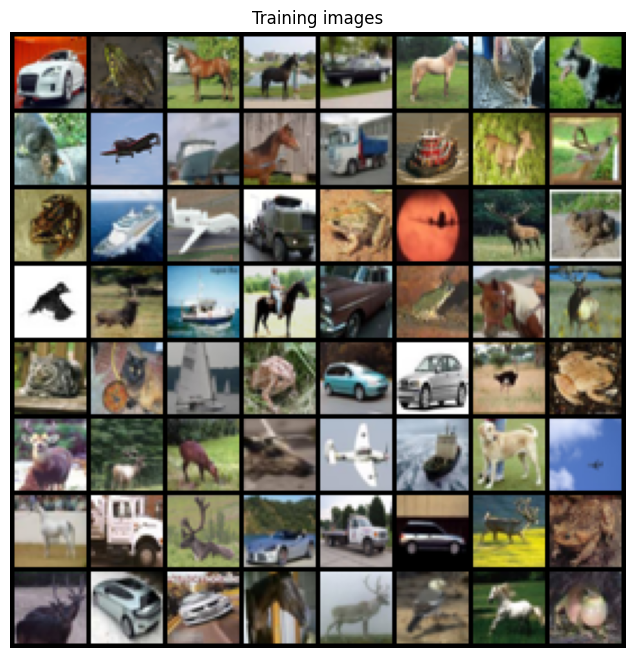

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torchvision


for images, labels in train_loader:  
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64], 
    padding=2,
    normalize=True),
    (1, 2, 0)))
plt.show()

- 0: airplane
- 1: automobile
- 2: bird
- 3: cat
- 4: deer
- 5: dog
- 6: frog
- 7: horse
- 8: ship
- 9: truck

In [31]:
class PyTorchCNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.cnn_layers = torch.nn.Sequential(

            torch.nn.Conv2d(3, 3, kernel_size=5, padding = "same"),
            torch.nn.BatchNorm2d(3),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            
            torch.nn.Conv2d(3, 16, kernel_size=3),
            torch.nn.BatchNorm2d(16),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),        
            
            torch.nn.Conv2d(16, 32, kernel_size=3),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2), 
        )
        
        self.fc_layers = torch.nn.Sequential(
            # hidden layer
            torch.nn.Linear(128, 20),
            torch.nn.BatchNorm1d(20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_classes)
        )

    def forward(self, x):
        x = self.cnn_layers(x)
        # print(x.shape)
        x = torch.flatten(x, start_dim=1)
        logits = self.fc_layers(x)
        return logits

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    avg_loss = total_loss / len(loader.dataset)
    avg_acc  = acc_metric.compute().item()
    return avg_loss, avg_acc

In [19]:
@inference_mode()
def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    avg_loss = total_loss / len(loader.dataset)
    avg_acc  = acc_metric.compute().item()
    return avg_loss, avg_acc

In [32]:
# --- Setup ---
torch.manual_seed(123)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = PyTorchCNN(num_classes=10).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

writer = SummaryWriter(log_dir="logs/cnn-mnist")

# Log model graph
dummy = torch.zeros(1, 3, 32, 32).to(device)
writer.add_graph(model, dummy)


In [26]:
MAX_EPOCHS = 10

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)

    # TensorBoard logging
    writer.add_scalars("Loss", {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": tr_acc, "val": vl_acc}, epoch)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val   Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

writer.close()


Epoch 01/10 | Train Loss: 1.5690  Acc: 0.4289 | Val   Loss: 1.7172  Acc: 0.3864
Epoch 02/10 | Train Loss: 1.3031  Acc: 0.5334 | Val   Loss: 2.9348  Acc: 0.2642
Epoch 03/10 | Train Loss: 1.2077  Acc: 0.5690 | Val   Loss: 1.3533  Acc: 0.5152
Epoch 04/10 | Train Loss: 1.1529  Acc: 0.5906 | Val   Loss: 1.5658  Acc: 0.4574
Epoch 05/10 | Train Loss: 1.1179  Acc: 0.6008 | Val   Loss: 1.4396  Acc: 0.5136
Epoch 06/10 | Train Loss: 1.0863  Acc: 0.6142 | Val   Loss: 1.6524  Acc: 0.4636
Epoch 07/10 | Train Loss: 1.0624  Acc: 0.6238 | Val   Loss: 1.9575  Acc: 0.4022
Epoch 08/10 | Train Loss: 1.0436  Acc: 0.6302 | Val   Loss: 2.0900  Acc: 0.4126
Epoch 09/10 | Train Loss: 1.0271  Acc: 0.6363 | Val   Loss: 1.3131  Acc: 0.5518
Epoch 10/10 | Train Loss: 1.0105  Acc: 0.6431 | Val   Loss: 1.5296  Acc: 0.4986
